
# Seaborn

Visualisierungen in Python mit Seaborn und Matplotlib. Seaborn basiert im Hintergrund auf Matplotlib und bietet eine einfachere API mit einem Standarddesign.

- Matplotlib: "Low-Level" – Man die volle Kontrolle über jedes Detail, musst aber alles manuell definieren.
- Seaborn: "High-Level" – Optimiert für statistische Daten (Pandas DataFrames) und ästhetische Standard-Designs.




## Grundlagen

### Matplotlib vs. Seaborn

- Matplotlib ist die Basis. Sie ist wie ein Werkzeugkasten, in dem man jede Schraube selbst drehen kann. Man hat die volle Kontrolle, braucht aber oft viele Zeilen Code für ein schönes Design.

- Seaborn ist ein Aufsatz für Matplotlib. Es ist spezialisiert auf statistische Datenvisualisierung und arbeitet perfekt mit Pandas DataFrames zusammen. Es erstellt mit sehr wenig Code ästhetisch ansprechende Grafiken und kümmert sich automatisch um Dinge wie Legenden und Farbschemata.

### Datensatz Tips

Seaborn bietet Beispiel Datensätze mit denen man die Funktionen ausprobieren kann.

Für unsere Notebooks verwenden wir den **Tips** Datensatz, der die folgenden Informationen über Restaurantbesuche beinhaltet:

- total_bill: Gesamtrechnung in Dollar.
- tip: Trinkgeld in Dollar.
- sex: Geschlecht der zahlenden Person.
- smoker: Ob in der Gruppe geraucht wurde.
- day/time: Wochentag und Tageszeit (Lunch/Dinner).
- size: Anzahl der Personen am Tisch.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn Design-Standard setzen
sns.set_theme()

# Datensatz laden
tips = sns.load_dataset("tips")

# Die ersten Zeilen anzeigen
print("Struktur des Tips-Datensatzes:")
display(tips.head())

# Kurze statistische Übersicht
print("\nStatistische Übersicht:")
display(tips.describe())

Struktur des Tips-Datensatzes:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



Statistische Übersicht:


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Liniendiagramm

Obwohl der tips-Datensatz keine echte Zeitreihe ist, können wir ein Liniendiagramm nutzen, um einen Trend zu zeigen (z.B. wie das Trinkgeld mit der Rechnungshöhe steigt, wenn man die Daten sortiert).

### Matplotlib

In Matplotlib müssen wir die Daten oft manuell vorbereiten (z.B. sortieren), damit die Linie nicht hin und her springt.

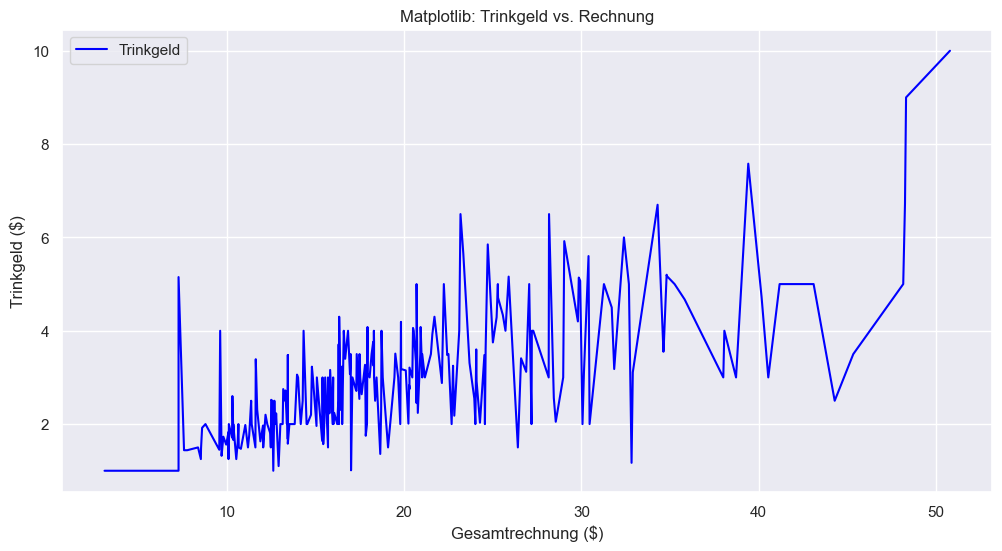

In [3]:
# Daten sortieren für eine saubere Linie
tips_sorted = tips.sort_values("total_bill")

plt.figure(figsize=(12, 6))
plt.plot(tips_sorted["total_bill"], tips_sorted["tip"], color="blue", label="Trinkgeld")
plt.title("Matplotlib: Trinkgeld vs. Rechnung")
plt.xlabel("Gesamtrechnung ($)")
plt.ylabel("Trinkgeld ($)")
plt.legend()
plt.show()

### Seaborn

Seaborn erledigt vieles im Hintergrund. Wir müssen die Daten nicht vorher sortieren. Zudem berechnet Seaborn bei sich überschneidenden Werten automatisch einen Durchschnitt und ein schattiertes Vertrauensintervall (Confidence Interval).

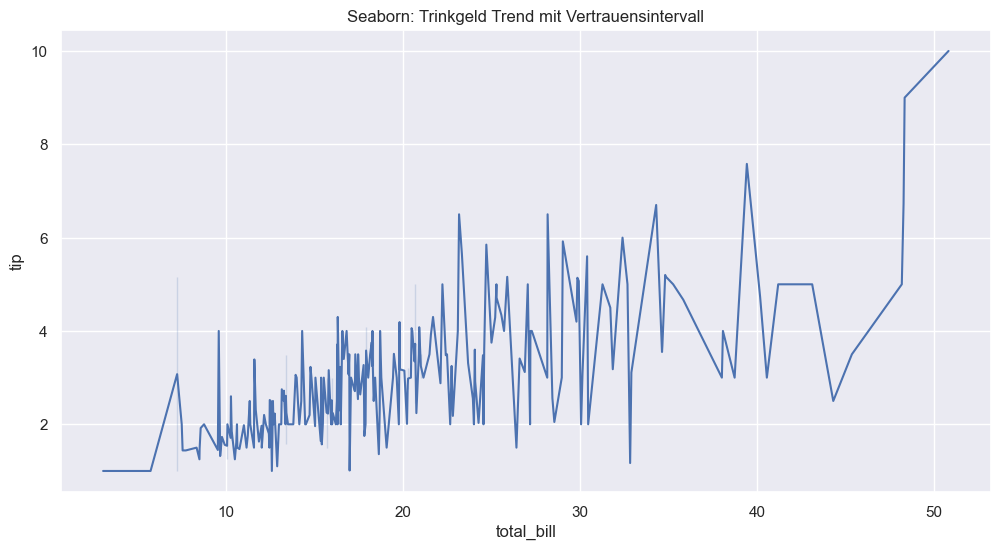

In [4]:
plt.figure(figsize=(12, 6))
# Ein Befehl für Daten, Achsen und Beschriftung
sns.lineplot(data=tips, x="total_bill", y="tip")

plt.title("Seaborn: Trinkgeld Trend mit Vertrauensintervall")
plt.show()

### Unterschiede

Was fällt auf
- In Matplotlib greifen wir mit df["Spalte"] auf die Daten zu.
- In Seaborn übergeben wir das gesamte Objekt data=tips und nennen nur die Namen der Spalten als Strings (x="total_bill"). Das macht den Code lesbarer.


**Exkurs Vertrauensintervall**

Das Vertrauensintervall (die Schattierung um die Linie) gibt an, wie sicher die Schätzung des Trends ist. Da in echten Datensätzen oft mehrere Messwerte für denselben X-Wert vorliegen (z. B. viele verschiedene Rechnungen über 20$), berechnet Seaborn den Mittelwert und zeigt mit der Schattierung den Bereich an, in dem der "wahre" Mittelwert mit einer Wahrscheinlichkeit von 95 % liegt.
- Schmale Schattierung: Viele Datenpunkte oder geringe Abweichungen – die Schätzung ist sehr präzise.
- Breite Schattierung: Wenige Datenpunkte oder starke Streuung – die Vorhersage ist unsicherer.

## Balkendiagramm

Beim Balkendiagramm zeigt sich einer der größten Vorteile von Seaborn: Es führt die Aggregation (Berechnung von Durchschnittswerten) automatisch durch.

### Matplotlib

In Matplotlib müssen wir die Daten zuerst mit Pandas gruppieren (groupby) und den Mittelwert berechnen, bevor wir sie plotten können.

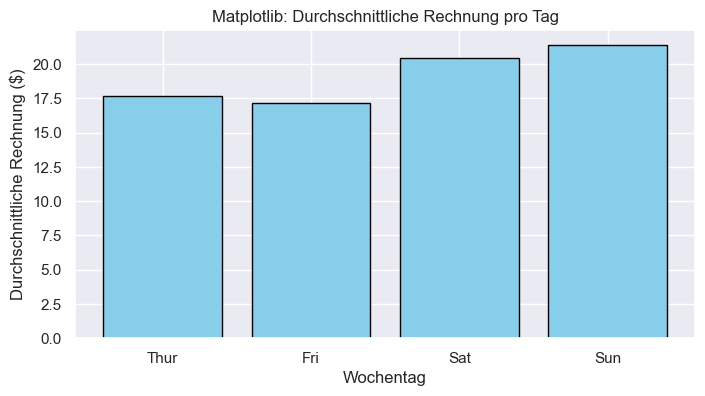

In [5]:
# Matplotlib benötigt vorbereitete (aggregierte) Daten
stats = tips.groupby("day", observed=True)["total_bill"].mean()     # Observed=True bedeutet, es werden nur die vorhandenen Kategorien
                                                                    # dargestellt und nicht alle möglichen (Mon bis Sun)

plt.figure(figsize=(8, 4))
plt.bar(stats.index, stats.values, color="skyblue", edgecolor="black")

plt.title("Matplotlib: Durchschnittliche Rechnung pro Tag")
plt.xlabel("Wochentag")
plt.ylabel("Durchschnittliche Rechnung ($)")
plt.show()

### Seaborn

Seaborn nimmt uns die Gruppierung ab. Wir geben einfach die Rohdaten an, und Seaborn berechnet den Mittelwert pro Kategorie von selbst. Zudem fügt es automatisch Error Bars (Fehlerbalken) hinzu, die die Unsicherheit der Mittelwerte zeigen.

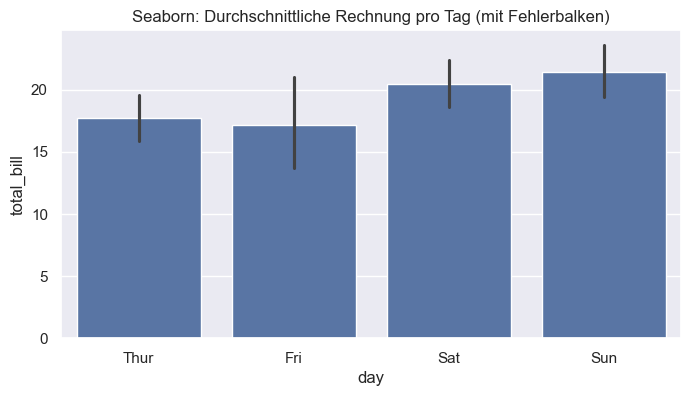

In [6]:
plt.figure(figsize=(8, 4))
# Seaborn berechnet den Mittelwert für 'total_bill' pro 'day' automatisch
sns.barplot(data=tips, x="day", y="total_bill")

plt.title("Seaborn: Durchschnittliche Rechnung pro Tag (mit Fehlerbalken)")
plt.show()

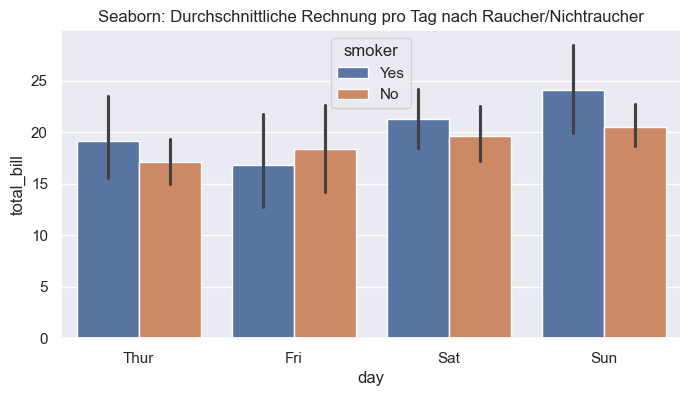

In [7]:
plt.figure(figsize=(8, 4))
sns.barplot(data=tips, x="day", y="total_bill", hue="smoker")

plt.title("Seaborn: Durchschnittliche Rechnung pro Tag nach Raucher/Nichtraucher")
plt.show()

### Unterschiede

Was fällt auf?
- Kein Vorverarbeiten bei Seaborn: Du sparst dir den groupby-Schritt in Pandas.
- Zusatzinformation: Die kleinen schwarzen Linien (Error Bars) zeigen dir sofort, wie stark die Rechnungsbeträge an den jeweiligen Tagen schwanken.
- Mit `hue` kann die Auswertung je angegbener Kategorie erfolgen.


**Exkurs Error Bars**

In Seaborn repräsentieren die Fehlerbalken standardmäßig das 95 %-Konfidenzintervall.

Die Bedeutung: Stell dir vor, du hast viele Daten für den "Samstag". Seaborn berechnet den Durchschnitt (den großen Balken). Da dieser Durchschnitt aber nur auf deiner aktuellen Stichprobe basiert, sagen die Fehlerbalken: "Wir sind uns zu 95 % sicher, dass der wahre Durchschnitt aller denkbaren Restaurantbesuche an Samstagen innerhalb dieses Bereichs liegt."
- Langer Fehlerbalken: Große Unsicherheit (vielleicht wenig Daten oder extrem unterschiedliche Rechnungsbeträge).
- Kurzer Fehlerbalken: Hohe Sicherheit (viele ähnliche Datenpunkte).

Möchte man die Anzeige ausblenden erfolgt dies mit dem Parameter **errorbar=None**. Dann wird nur der Durchschnitt angezeigt.

## Histogramm und KDE

Hier vergleichen wir, wie man die Verteilung der Rechnungsbeträge (total_bill) darstellt. Zudem schauen wir die Seaborn Option KDE (Kernel Desity Estimation) an.

### Matplotlib

In Matplotlib ist ein Histogramm einfach, aber für eine geglättete Kurve (KDE - Kernel Density Estimate) müsste man zusätzliche Bibliotheken wie scipy bemühen oder die Mathematik selbst implementieren.

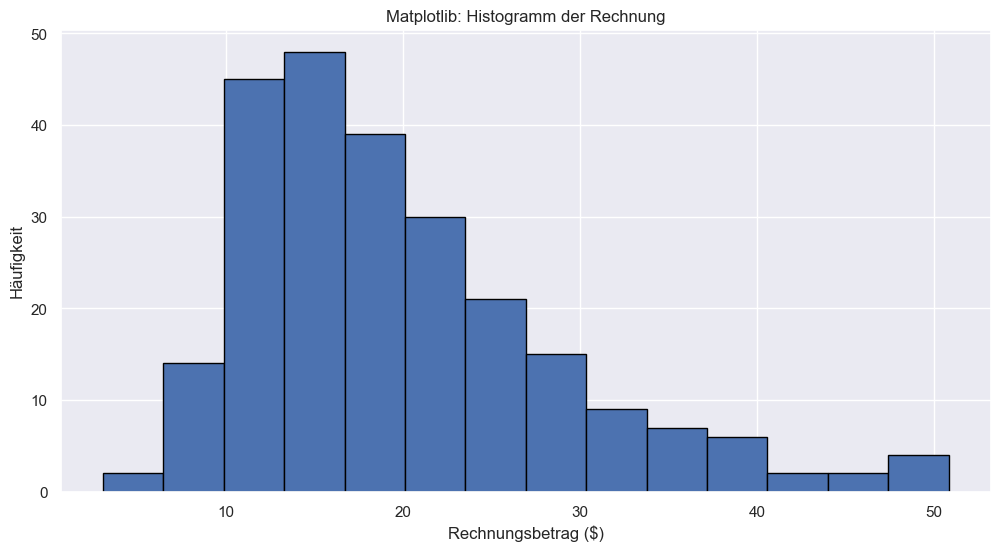

In [8]:
plt.figure(figsize=(12, 6))
# Ein einfaches Histogramm
plt.hist(tips["total_bill"], bins=14, edgecolor="black")

plt.title("Matplotlib: Histogramm der Rechnung")
plt.xlabel("Rechnungsbetrag ($)")
plt.ylabel("Häufigkeit")
plt.show()

### Seaborn

Seaborn bietet mit displot oder histplot eine extrem einfache Lösung, um das Histogramm mit einer KDE-Kurve zu kombinieren.

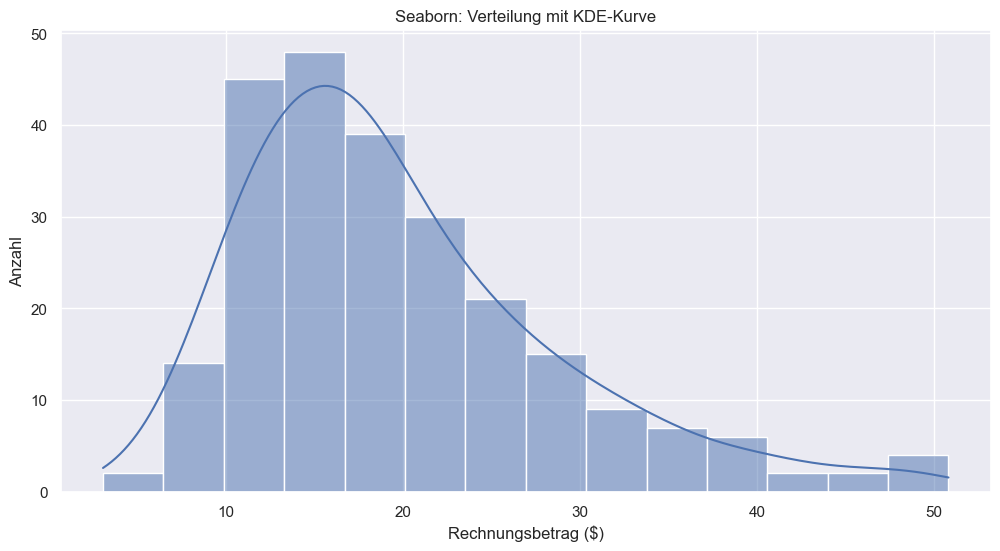

In [9]:
plt.figure(figsize=(12, 6))
# Histogramm + geglättete Kurve (KDE)
sns.histplot(data=tips, x="total_bill", kde=True)

plt.title("Seaborn: Verteilung mit KDE-Kurve")
plt.xlabel("Rechnungsbetrag ($)")
plt.ylabel("Anzahl")
plt.show()

### Unterschiede

Was fällt auf?

- Mit Seaborn erhlält man einfach die Kombination von zwei Informationsebenen (die exakten Balken und den allgemeinen Trend der Kurve) in einer einzigen Zeile Code.
- Skalierung: Seaborn berechnet die Dichte der Kurve automatisch so, dass sie perfekt über das Histogramm passt.

**Exkurs KDE**

Die KDE (Kernel Density Estimation) ist eine geglättete Version des Histogramms. Sie hilft dabei, die Form der Verteilung besser zu erkennen, ohne von der Wahl der Balkenanzahl (bins) abgelenkt zu werden.

## Scatterplot

Hier vergleichen wir die Beziehung zwischen Gesamtrechnung (total_bill) und Trinkgeld (tip) anhand einer Kategorie.

### Matplotlib

In Matplotlib ist es mühsam, die Punkte nach einer Kategorie (z. B. Geschlecht) einzufärben. Man muss für jede Kategorie einen eigenen Plot-Aufruf starten oder eine Farb-Map manuell erstellen.

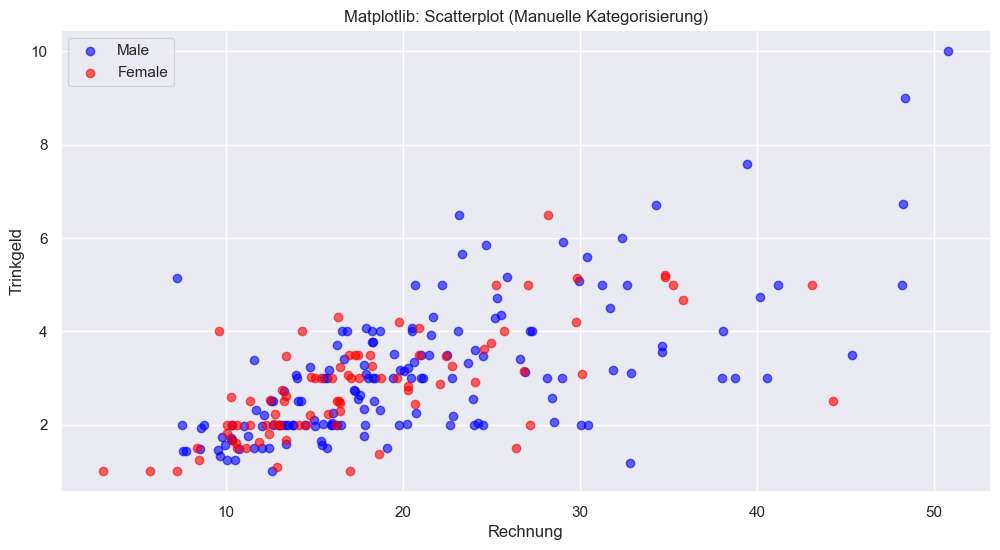

In [10]:
plt.figure(figsize=(12, 6))

# Manuelles Filtern für Kategorien in Matplotlib
for gender, color in zip(["Male", "Female"], ["blue", "red"]):
    subset = tips[tips["sex"] == gender]
    plt.scatter(subset["total_bill"], subset["tip"], label=gender, alpha=0.6, color=color)

plt.title("Matplotlib: Scatterplot (Manuelle Kategorisierung)")
plt.xlabel("Rechnung")
plt.ylabel("Trinkgeld")
plt.legend()
plt.show()

### Seaborn

Seaborn erledigt das Mapping von Kategorien auf Farben (hue) und sogar auf verschiedene Punktformen (style) in einer Zeile und erstellt die Legende automatisch.

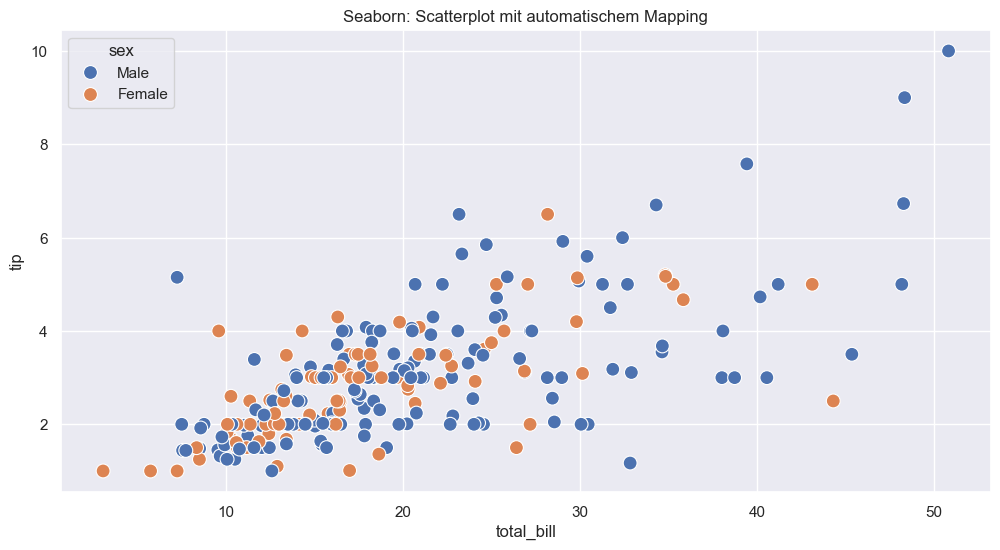

In [11]:
plt.figure(figsize=(12, 6))
# 'hue' färbt nach Geschlecht, 'style' ändert das Symbol nach Raucherstatus
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex", s=100)

plt.title("Seaborn: Scatterplot mit automatischem Mapping")
plt.show()

**Multidimensionalität**:

Mit Seaborn können bis zu vier Dimensionen (X, Y, Farbe, Symbolform/Größe) in einem 2D-Plot angezeigt werden:

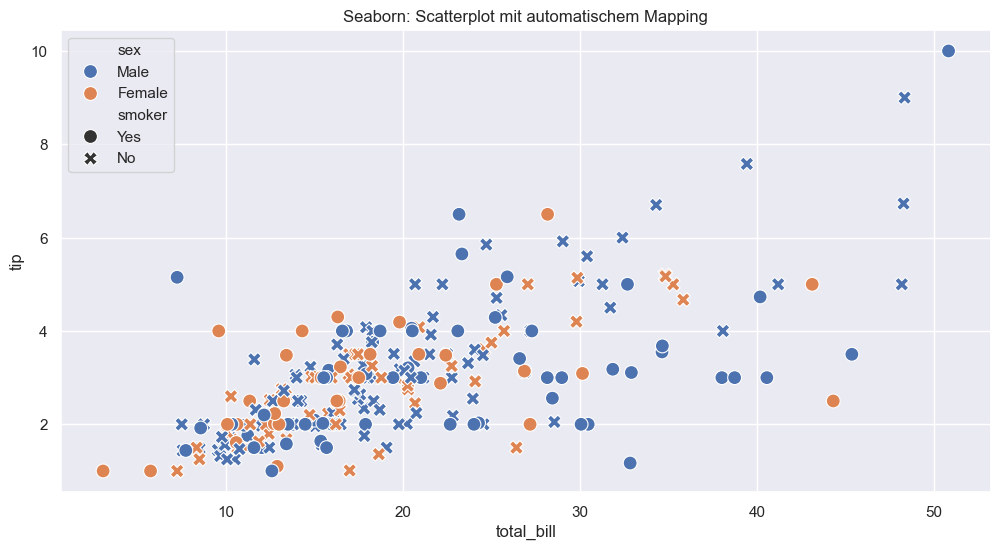

In [12]:
plt.figure(figsize=(12, 6))
# 'hue' färbt nach Geschlecht, 'style' ändert das Symbol nach Raucherstatus
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex", style="smoker", s=100)

plt.title("Seaborn: Scatterplot mit automatischem Mapping")
plt.show()

## Boxplot

Der Boxplot ist quasi der "große Bruder" des Balkendiagramms. Während der Balken nur den Mittelwert zeigt, liefert der Boxplot eine vollständige statistische Zusammenfassung.


- Die **Box** enthält die **mittleren 50%** der Daten (Interquartilsabstand).
- Der **Strich** in der Box zeigt den **Median** (der Wert, der genau in der Mitte liegt).
- Die **Antennen** (Whiskers) zeigen die **Reichweite der restlichen Daten**.
- Die **Punkte** zeigen **Ausreißer**, Extremwerte die statistisch weit vom Rest entfernt sind.

### Matplotlib

In Matplotlib ist die Logik wieder etwas aufwendiger, da man oft eine Liste von Listen (pro Tag eine Liste mit Rechnungen) vorbereiten muss.

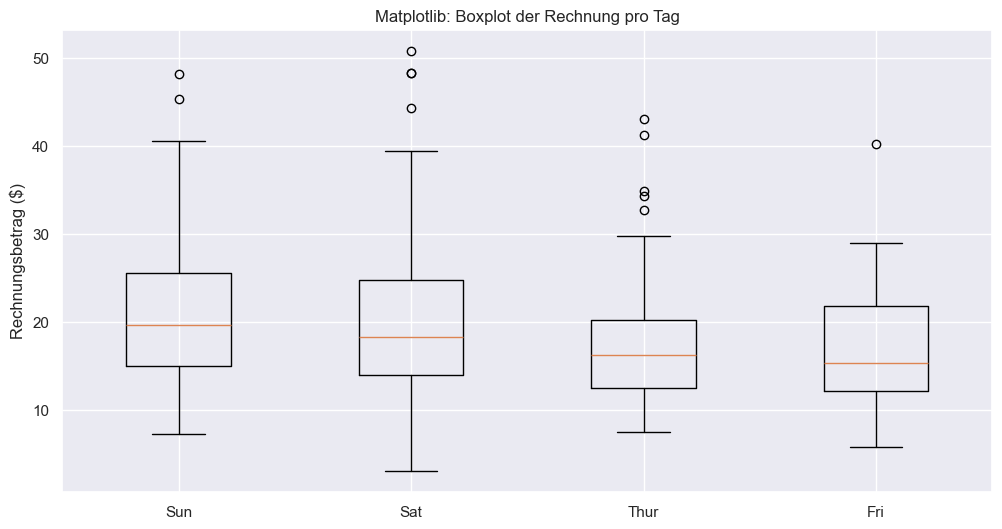

In [13]:
# Daten für Matplotlib vorbereiten (Liste von Serien pro Tag)
days = tips["day"].unique()
data_list = [tips[tips["day"] == d]["total_bill"] for d in days]

plt.figure(figsize=(12, 6))
plt.boxplot(data_list, tick_labels=days)

plt.title("Matplotlib: Boxplot der Rechnung pro Tag")
plt.ylabel("Rechnungsbetrag ($)")
plt.show()

### Seaborn

Seaborn macht das automatisch für alle Kategorien auf der X-Achse und sorgt für ein modernes Design. Mit palette kann eine Farbpalette für die einzelnen Boxplots angegeben werden.

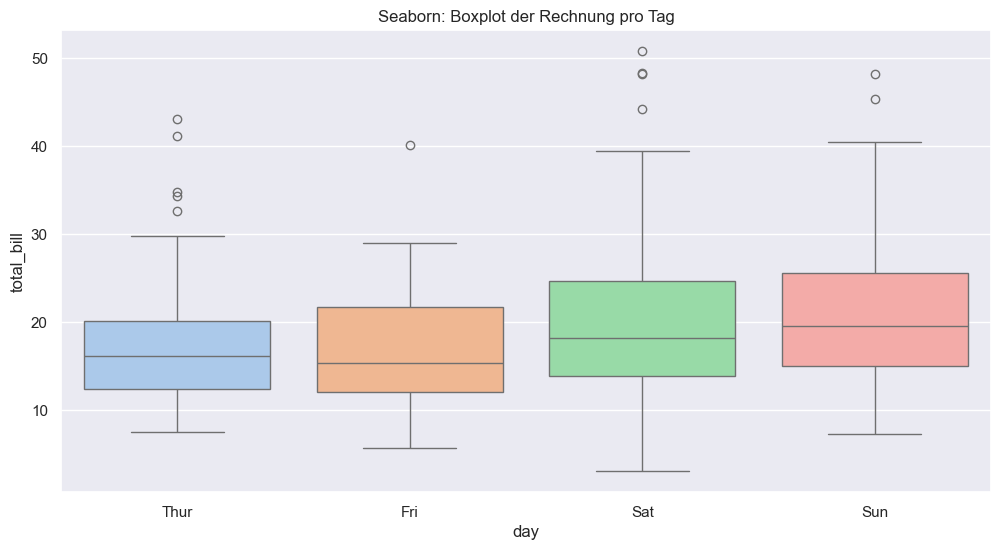

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=tips, x="day", y="total_bill", hue="day", palette="pastel", legend=False)

plt.title("Seaborn: Boxplot der Rechnung pro Tag")
plt.show()

# Seaborn Data Discovery

Mit den folgenden Seaborn Diagrammen können **statistische Zusammenhänge** schnell und elegant visualisiert werden.

## Pairplot (Matrix-Diagramm)

Der pairplot ist das ultimative Werkzeug für die erste Datenexploration. Er erstellt eine Matrix von Diagrammen, die jede numerische Spalte mit jeder anderen vergleicht.

- In der Diagonale: Die Verteilung (Histogramm) der jeweiligen Variable.
- Außerhalb: Scatterplots, um Korrelationen zwischen zwei Variablen zu finden.

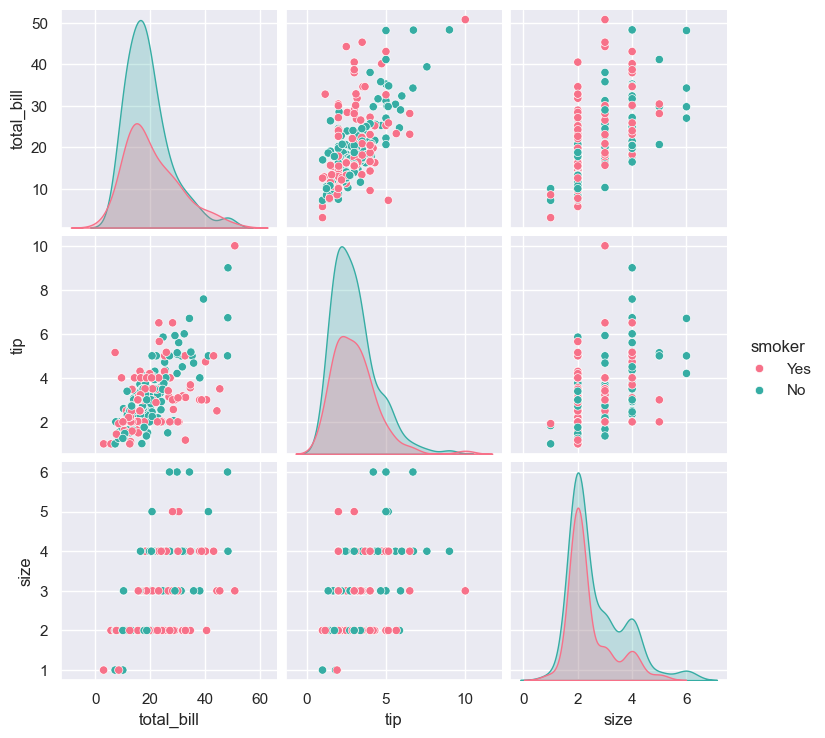

In [15]:
# Analysiere alle numerischen Beziehungen auf einmal
# 'hue' färbt die Punkte nach einer Kategorie (z.B. Raucher)
sns.pairplot(data=tips, hue="smoker", palette="husl")
plt.show()

> Mit einem einzigen Befehl sieht man sofort, ob es Zusammenhänge zwischen Rechnunghöhe, Trinkgeld und Gruppengröße gibt – getrennt nach Rauchern.

## Heatmap (Korrelationsmatrix)

Eine Heatmap visualisiert Zahlenwerte durch Farben. Besonders nützlich ist sie, um die Korrelationsmatrix eines DataFrames darzustellen. Die Heatmap zeigt an wie stark die Variablen zusammenhängen.

**Details:**

- annot=True: Schreibt die Zahlen direkt in die Kästchen.
- cmap="coolwarm": Blau bedeutet negative Korrelation, Rot bedeutet positive Korrelation.
- fmt=".2f": Rundet die Zahlen auf zwei Nachkommastellen.

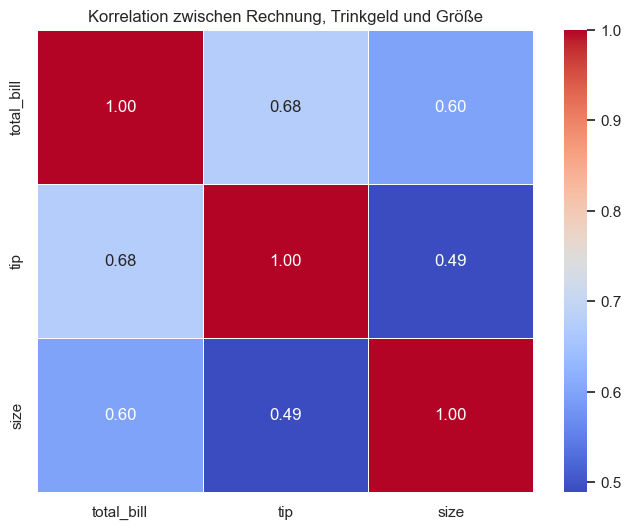

In [16]:
# 1. Korrelationsmatrix berechnen (nur für Zahlen)
corr = tips.select_dtypes(include='number').corr()

# 2. Heatmap zeichnen
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Korrelation zwischen Rechnung, Trinkgeld und Größe")
plt.show()

## Jointplot

Ein jointplot kombiniert einen Scatterplot mit den jeweiligen Histogrammen an den Achsen. So siehst du die Beziehung zweier Variablen und ihre Einzelverteilungen gleichzeitig.

**Details:**

- Durch kind="reg" fügt Seaborn automatisch eine Regressionslinie hinzu, die den statistischen Trend zeigt.

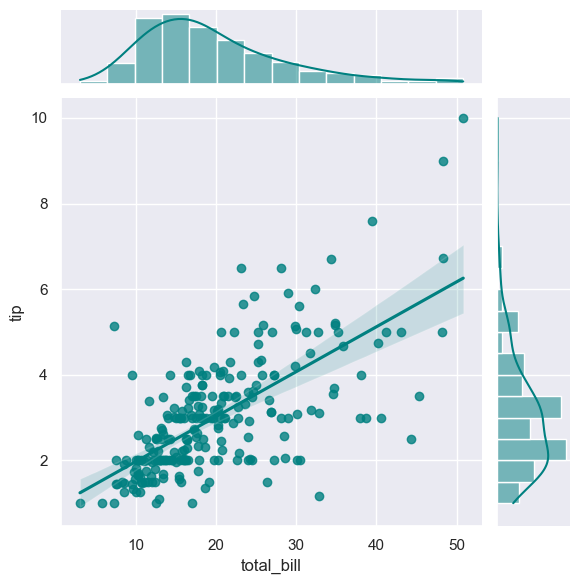

In [17]:
# Beziehung zwischen Rechnung und Trinkgeld mit Rand-Verteilungen
sns.jointplot(data=tips, x="total_bill", y="tip", kind="reg", color="teal")
plt.show()

# Seaborn Colors

Seaborn ist berühmt für seine Farbpaletten, die wissenschaftlich so entwickelt wurden, dass sie sowohl ästhetisch ansprechend als auch gut lesbar sind.

## Herkunft

Mit dem Parameter `palette` kann eine Farbpalette ausgewählt werden. Seaborn kennt dabei zwei Herkunftstypen:

 - **Matplotlib/ColorBrewer Namen**: (`Paired`, `Set1`, `Set2`, `Tab10`, `Viridis`) – diese halten sich an die offizielle Schreibweise von Matplotlib, die oft mit einem Großbuchstaben beginnt.
 - **Seaborn-eigene Namen**: (`deep`, `muted`, `bright`, `pastel`, `dark`, `colorblind`, `rocket`, `mako`, `flare`, `crest`) – diese sind meist kleingeschrieben.



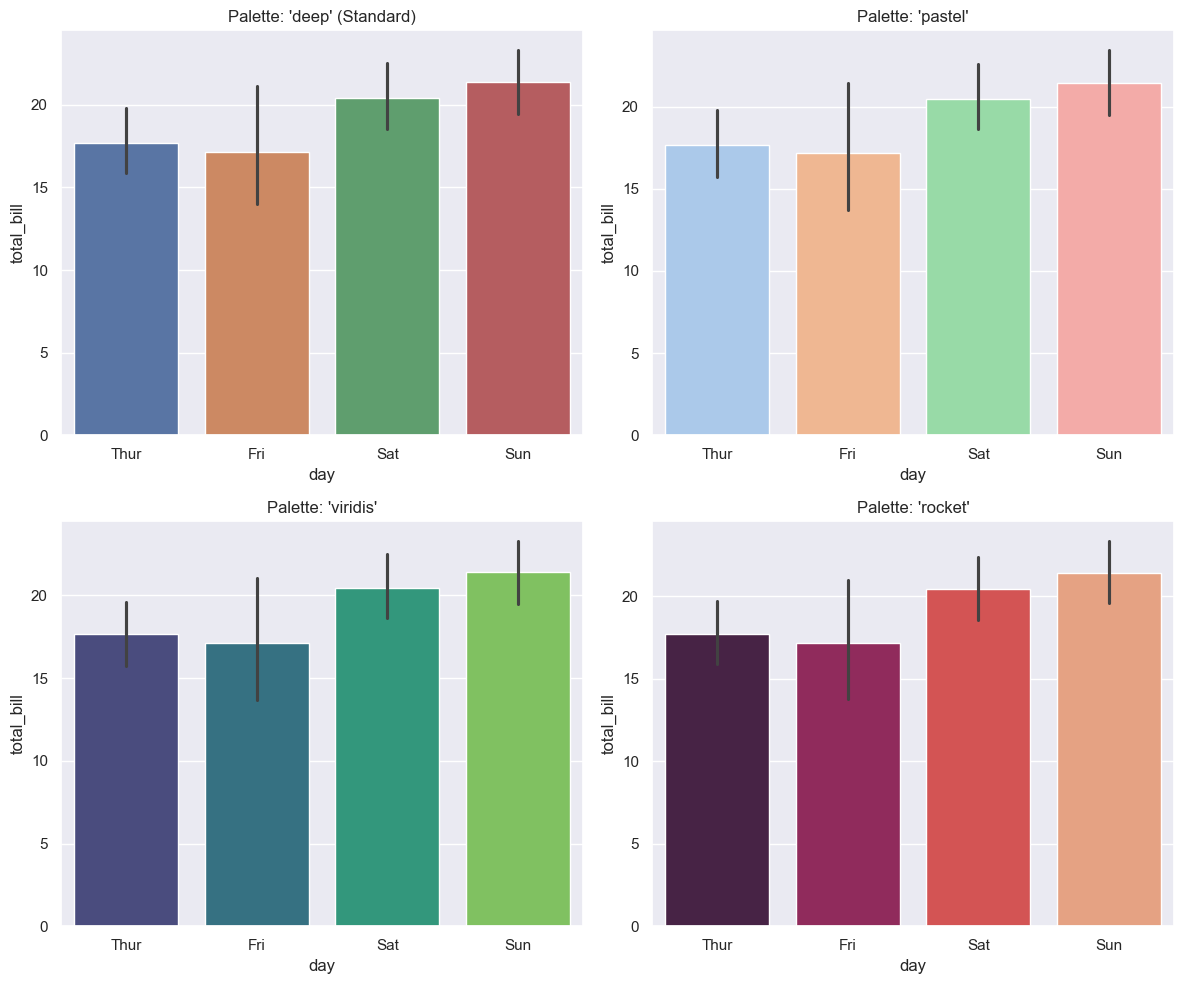

In [18]:
# Wir erstellen ein Grid mit 2x2 Plots, um Paletten zu vergleichen
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 'deep' - Der Seaborn Klassiker (dezent & modern)
sns.barplot(data=tips, x="day", y="total_bill", hue="day", palette="deep", ax=axes[0,0], legend=False)
axes[0,0].set_title("Palette: 'deep' (Standard)")

# 2. 'pastel' - Sanfte Farben für einen hellen Look
sns.barplot(data=tips, x="day", y="total_bill", hue="day", palette="pastel", ax=axes[0,1], legend=False)
axes[0,1].set_title("Palette: 'pastel'")

# 3. 'viridis' - Wissenschaftlicher Standard (farbenblind-freundlich)
sns.barplot(data=tips, x="day", y="total_bill", hue="day", palette="viridis", ax=axes[1,0], legend=False)
axes[1,0].set_title("Palette: 'viridis'")

# 4. 'rocket' - Sequenziell (gut für Intensitäten)
sns.barplot(data=tips, x="day", y="total_bill", hue="day", palette="rocket", ax=axes[1,1], legend=False)
axes[1,1].set_title("Palette: 'rocket'")

plt.tight_layout()
plt.show()

## Datenart

Seaborn bietet je nach Art der Daten verschiedene Farbpaletten an:
- Qualitative Paletten: Für unterschiedliche Kategorien (z. B. "Raucher" vs. "Nichtraucher").
- Sequenzielle Paletten: Für numerische Steigerungen (z. B. niedriges bis hohes Einkommen).
- Divergierende Paletten: Für Abweichungen von einem Mittelpunkt (z. B. Temperatur: kalt bis heiß).

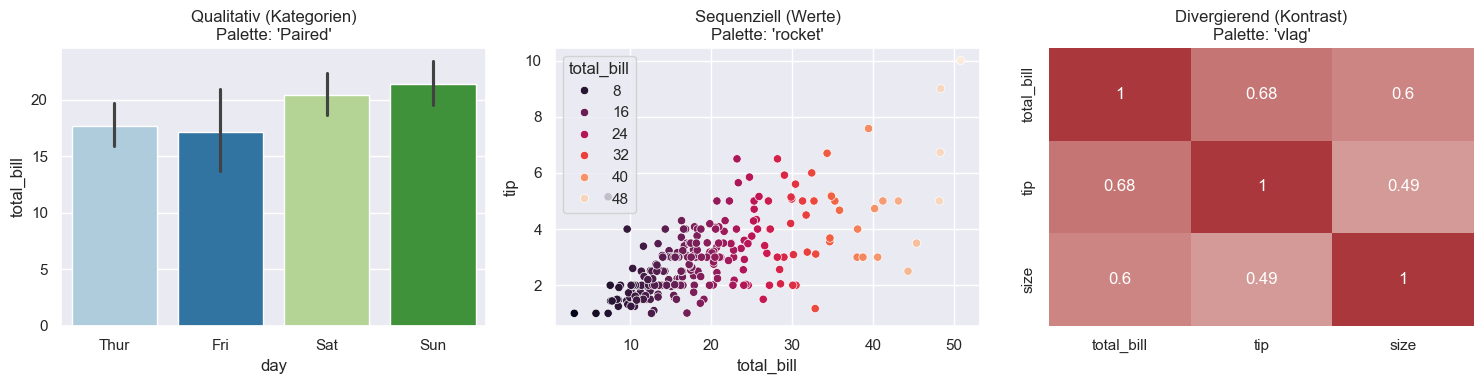

In [19]:
# 1. Qualitative Paletten (Für Kategorien ohne Rangfolge)
# Beispiel: Wochentage oder Geschlecht
pal_qual = sns.color_palette("Paired", 10)

# 2. Sequenzielle Paletten (Für numerische Steigerungen)
# Beispiel: Höhe der Rechnung oder Temperatur
pal_seq = sns.color_palette("rocket", as_cmap=False)

# 3. Divergierende Paletten (Abweichungen von einem neutralen Mittelpunkt)
# Beispiel: Korrelationen (negativ vs. positiv) oder Gewinne/Verluste
pal_div = sns.color_palette("coolwarm", 10)

# Visualisierung im Vergleich
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Qualitative (Kategorien)
sns.barplot(data=tips, x="day", y="total_bill", hue="day", palette="Paired", ax=axes[0], legend=False)
axes[0].set_title("Qualitativ (Kategorien)\nPalette: 'Paired'")

# Plot 2: Sequenziell (Intensität)
# Wir nutzen hier eine numerische Variable für die Farbe
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="total_bill", palette="rocket", ax=axes[1])
axes[1].set_title("Sequenziell (Werte)\nPalette: 'rocket'")

# Plot 3: Divergierend (Kontrast)
# Hier nutzen wir die Korrelationsmatrix als Beispiel
corr = tips.select_dtypes(include='number').corr()
sns.heatmap(corr, cmap="vlag", annot=True, center=0, ax=axes[2], cbar=False)
axes[2].set_title("Divergierend (Kontrast)\nPalette: 'vlag'")

plt.tight_layout()
plt.show()

## Auswahl

### Aktuelle Palette

Mit dem Befehl `color_palette()` wird die aktuelle Color Palette angezeigt. Wenn keine expliziten Angabe bei einer Grafik angegeben wird, so kommt diese Palette zum Zug.

In [20]:
sns.color_palette()

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

### Beliebte Paletten

Beim Befehl `color_palette(name, n)` kann auch eine beliebige Palette und die Anzahl der Farben angegeben werden. Damit kann man sehr einfach die vorhandenen Paletten anzeigen.

Das folgende Beispiel zeigt einige der beliebtesten Paletten:
- `viridis` (Sequenziell): Der Goldstandard. Sie ist farbenblind-freundlich und sieht auch im Schwarz-Weiß-Druck perfekt aus.
- `rocket` (Sequenziell): Sehr modern, von Dunkelrot/Schwarz zu hellem Gelb. Ideal für Heatmaps.
- `Paired` (Qualitativ): Perfekt, wenn du Kategorien hast, die zusammengehören (z.B. "Hellblau" für Gruppe A1 und "Dunkelblau" für Gruppe A2).
- `Set2` (Qualitativ): Sehr ästhetische, matte Farben, die professioneller wirken als die knalligen Standardfarben.
- `coolwarm` (Divergierend): Der Klassiker für Korrelationen oder Temperaturunterschiede (Blau = Kalt/Negativ, Rot = Warm/Positiv).

Palette: viridis


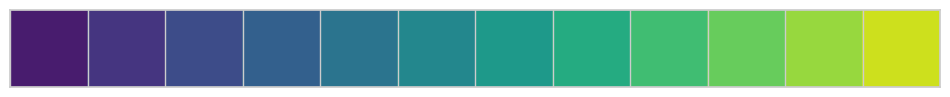

Palette: rocket


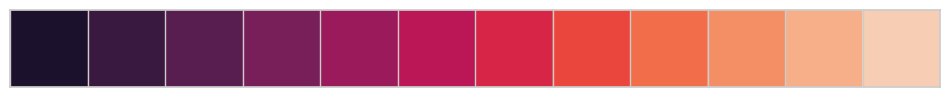

Palette: Paired


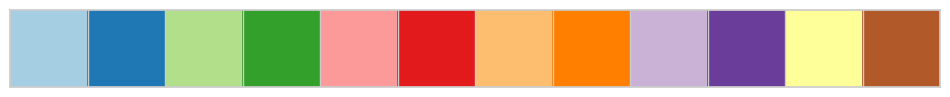

Palette: Set2


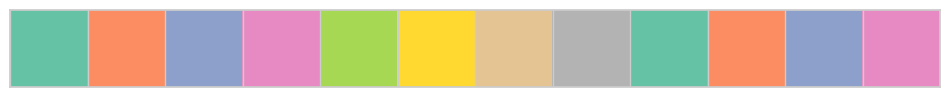

Palette: coolwarm


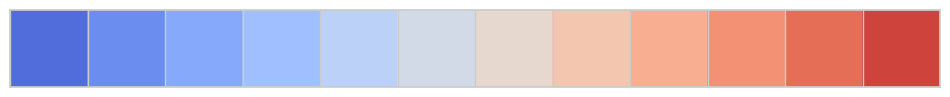

In [21]:

pals = ["viridis", "rocket", "Paired", "Set2", "coolwarm"]

for p in pals:
    print(f"Palette: {p}")
    sns.palplot(sns.color_palette(p, 12))
    plt.show()

### Paletten nach Datenart

Anbei die Farbpaletten je Art der Daten:

**Qualitative Paletten (Kategorial)**

Diese nutzt du für Daten ohne Rangfolge (z.B. verschiedene Abteilungen, Tierarten oder Länder). Die Farben sind so gewählt, dass sie gut voneinander unterscheidbar sind.
- Seaborn Standards: deep, muted, bright, pastel, dark, colorblind.
- Matplotlib Klassiker: Set1, Set2, Set3, Paired, Accent, tab10.

Palette: deep


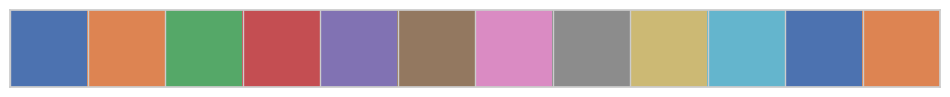

Palette: muted


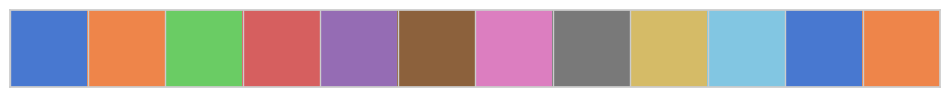

Palette: bright


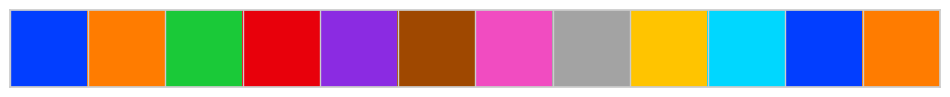

Palette: pastel


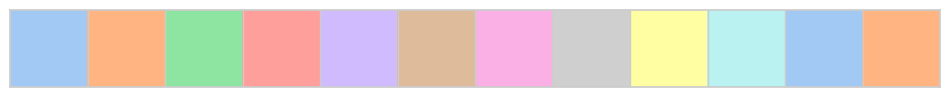

Palette: dark


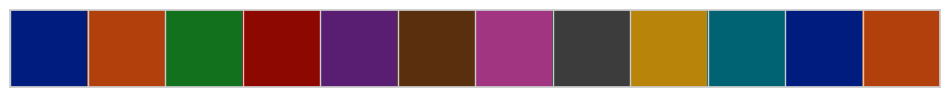

Palette: colorblind


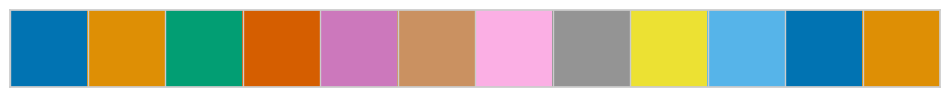

In [22]:
pals = ["deep", "muted", "bright", "pastel", "dark", "colorblind"]

for p in pals:
    print(f"Palette: {p}")
    sns.palplot(sns.color_palette(p, 12))
    plt.show()

**Sequenzielle Paletten (Verlauf)**

Diese eignen sich für numerische Daten, die von "wenig" zu "viel" verlaufen (z. B. Alter, Preis, Geschwindigkeit).
- Perzeptuell gleichmäßige Paletten: viridis, plasma, inferno, magma, cividis. (Diese sind besonders gut, weil die Helligkeit linear ansteigt).
- Seaborn-spezifisch: rocket, mako, flare, crest.
- Einfache Verläufe: Blues, Reds, Greens, YlOrBr (Yellow-Orange-Brown).

Palette: viridis


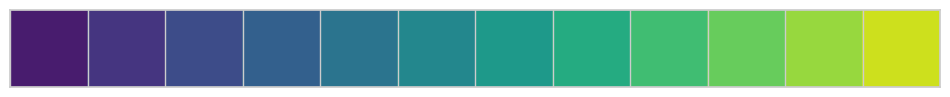

Palette: plasma


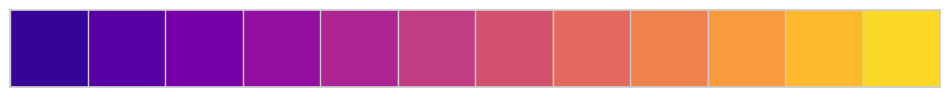

Palette: inferno


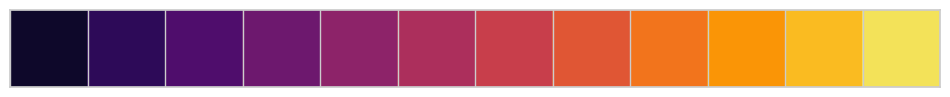

Palette: magma


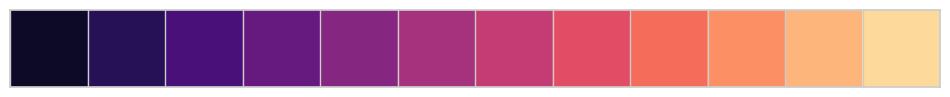

Palette: cividis


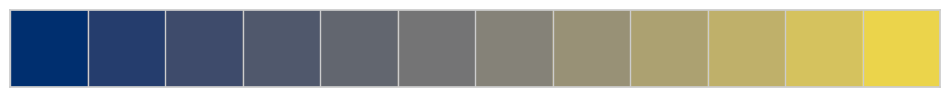

Palette: rocket


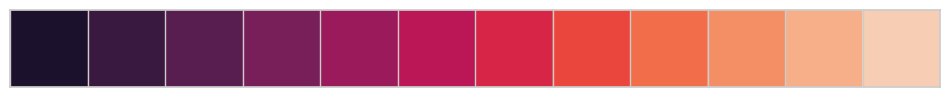

Palette: mako


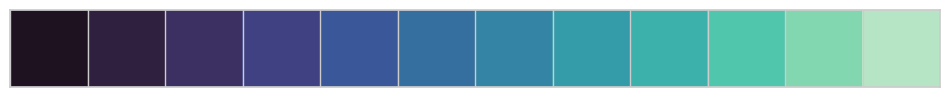

Palette: flare


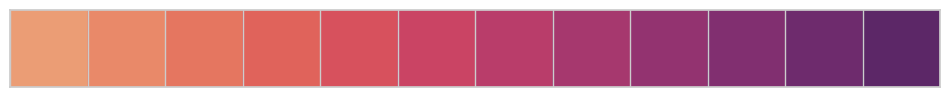

Palette: crest


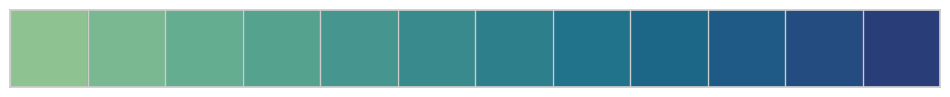

In [23]:
pals = ["viridis", "plasma", "inferno", "magma", "cividis", "rocket", "mako", "flare", "crest"]

for p in pals:
    print(f"Palette: {p}")
    sns.palplot(sns.color_palette(p, 12))
    plt.show()

**Divergierende Paletten (Zwei Pole)**

Diese nutzt du, wenn deine Daten einen wichtigen neutralen Mittelpunkt haben (z. B. Korrelationen von -1 bis +1, Temperaturabweichungen oder Profit vs. Verlust).
- Klassiker: coolwarm, RdBu (Red-Blue), vlag, icefire, Spectral, BrBG (Brown-Beverage-Green).

Palette: coolwarm


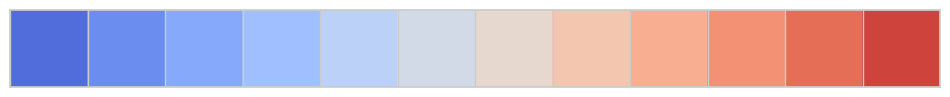

Palette: RdBu


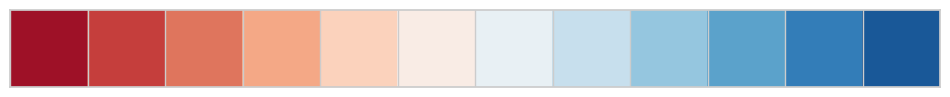

Palette: vlag


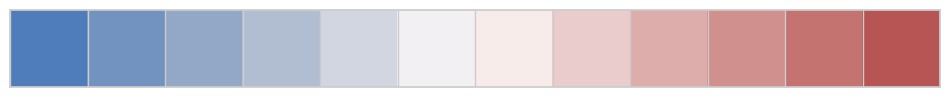

Palette: icefire


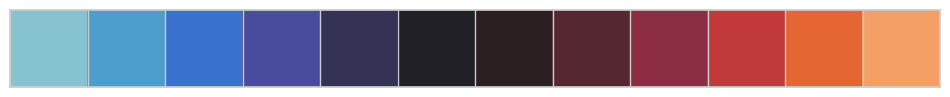

Palette: Spectral


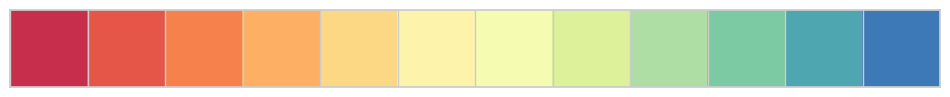

Palette: BrBG


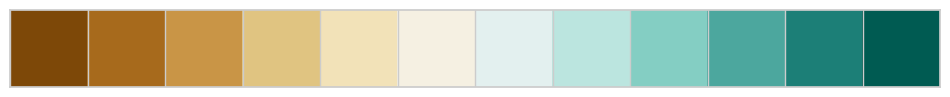

In [24]:
pals = ["coolwarm", "RdBu", "vlag", "icefire", "Spectral", "BrBG"]

for p in pals:
    print(f"Palette: {p}")
    sns.palplot(sns.color_palette(p, 12))
    plt.show()